# Insurance Claims Fraud Detection Analysis

## Objective
To analyze insurance claims data and identify patterns that indicate potential fraud using Python-based data analysis.

## Dataset
Synthetic dataset simulating real-world insurance claim scenarios including claim amount, reporting lag, vehicle age, and fraud indicators.

## Workflow

1. Data Loading  
2. Data Cleaning  
3. Feature Engineering  
4. Fraud Logic Creation  
5. Data Realism Adjustment  
6. Analysis & Visualization  
7. Final Summary & Recommendations

### 1. Data Loading

In [28]:
import pandas as pd

df = pd.read_csv('claims_data_v2.csv')

df.head()

,Claim_Number,Policy_Number,Customer_ID,Vehicle_Age,IDV,Claim_Amount,Loss_Date,Intimation_Date,Claim_Cause,Garage_ID,Location
0,CLM0001,POL235,CUST475,4,548964.80,325505.1841,14-10-2024 21:41,17-10-2024 21:41,Minor Accident,GAR044,Chennai
1,CLM0002,POL113,CUST201,9,332245.65,148225.0028,05-05-2024 06:06,05-05-2024 06:06,Flood Damage,GAR010,Coimbatore
2,CLM0003,POL275,CUST365,10,393977.00,291883.4230,25-08-2023 14:20,25-08-2023 14:20,Major Accident,GAR014,Bangalore
3,CLM0004,POL018,CUST075,8,337347.00,217288.0530,31-05-2024 15:44,01-06-2024 15:44,Major Accident,GAR039,Coimbatore
4,CLM0005,POL387,CUST622,5,547510.50,429122.4736,22-05-2023 10:54,29-05-2023 10:54,Theft,GAR035,Coimbatore


### 2. Data Cleaning

In [29]:
df.isnull().sum()

df['Loss_Date'] = pd.to_datetime(df['Loss_Date'])
df['Intimation_Date'] = pd.to_datetime(df['Intimation_Date'])


df['Claim_Amount'] = df['Claim_Amount'].fillna(df['Claim_Amount'].median())
df['Claim_Cause'] = df['Claim_Cause'].fillna('Unknown')


df = df.dropna(subset=['Loss_Date', 'Intimation_Date'])

# Create Reporting Lag
df['Reporting_Lag'] = (df['Intimation_Date'] - df['Loss_Date']).dt.days

C:\Users\DELL\AppData\Local\Temp\ipykernel_14272\466209887.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Loss_Date'] = pd.to_datetime(df['Loss_Date'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_14272\466209887.py:4: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Intimation_Date'] = pd.to_datetime(df['Intimation_Date'])


### 3. Feature Engineering

In [30]:
# -------------------------------
# 3.1 Claim Percentage (Financial Stress Indicator)
# -------------------------------
# Measures how much of the insured value is being claimed
# High ratio → suspicious (possible over-claiming)

df['Claim_Percentage'] = df['Claim_Amount'] / df['IDV']


# -------------------------------
# 3.2 Claim Frequency (Behavioral Pattern)
# -------------------------------
# Number of claims made per policy
# Frequent claims → higher fraud suspicion

claim_counts = df.groupby('Policy_Number')['Claim_Number'].count()
df['Claim_Frequency'] = df['Policy_Number'].map(claim_counts)


# -------------------------------
# 3.3 Fast Claim Flag (Suspicious Speed)
# -------------------------------
# Extremely fast reporting + very high claim → staged fraud possibility

df['Fast_Claim_Flag'] = (
    (df['Reporting_Lag'] <= 1) &
    (df['Claim_Percentage'] > 0.9)
)

# -------------------------------
# 3.4 Late Reporting Flag (Refined Threshold)
# -------------------------------
# Secondary threshold to capture moderate delays

df['Late_Reporting_Flag'] = df['Reporting_Lag'] > 2


# -------------------------------
# 3.5 Multiple Claims Flag
# -------------------------------
# Same policy making multiple claims → repeated behavior risk

df['Multiple_Claims_Flag'] = (
    (df['Claim_Frequency'] > 1) &
    (df['Vehicle_Age'] > 5)
)


# -------------------------------
# 3.6 High Claim Percentage Flag
# -------------------------------
# High % of IDV claimed → financial anomaly

df['High_Claim_Flag'] = df['Claim_Percentage'] > 0.8


# -------------------------------
# 3.7 Total Loss Pattern Flag
# -------------------------------
# Old vehicle + high claim % + specific claim causes

df['Total_Loss_Flag'] = (
    (df['Vehicle_Age'] > 7) &
    (df['Claim_Percentage'] > 0.9) &
    (df['Claim_Cause'].isin(['Fire', 'Flood Damage']))
)


# -------------------------------
# 3.8 Garage-Level Fraud Clustering
# -------------------------------
# Identify suspicious garages with unusually high claim volume

garage_claim_pattern = (
    df.groupby(['Garage_ID', 'Claim_Cause'])['Claim_Number']
    .count()
)

df['Garage_Claim_Pattern_Count'] = list(
    zip(df['Garage_ID'], df['Claim_Cause'])
)

df['Garage_Claim_Pattern_Count'] = (
    df['Garage_Claim_Pattern_Count']
    .map(garage_claim_pattern)
)

df['Cluster_Fraud_Flag'] = (
    df['Garage_Claim_Pattern_Count'] > 15
)


**These engineered fraud indicators were later used for operational fraud concentration and co-occurrence analysis.**

### 4. Fraud Logic

In [31]:
# ================================
# 4. FRAUD SCORING LOGIC
# Combines multiple engineered fraud indicators into a final risk score
# ================================

df['Fraud_Score'] = (
    df['Late_Reporting_Flag'].astype(int) +
    df['Multiple_Claims_Flag'].astype(int) +
    df['High_Claim_Flag'].astype(int) +
    df['Total_Loss_Flag'].astype(int) +
    df['Cluster_Fraud_Flag'].astype(int) +
    df['Fast_Claim_Flag'].astype(int)
)

# Threshold: Minimum 2 risk signals required to classify as fraud
df['Final_Fraud_Flag'] = df['Fraud_Score'] >= 2

### 5. Data Realism Adjustment

**Observation:**
The dataset showed overly clean and deterministic fraud patterns due to rule-based labeling.

**Improvement:**
To better simulate real-world uncertainty, a small amount of controlled variation (noise) was introduced into the fraud labels.

**Note:**
All analyses below are recomputed after this adjustment.

After introducing controlled noise into the fraud labels, the dataset was re-segmented into fraud and non-fraud groups to ensure all subsequent analyses reflect the updated classification.

In [32]:
import numpy as np

# Controlled Noise Injection: Simulates real-world misclassification in fraud detection systems
np.random.seed(42)

noise_ratio = 0.05

noise_indices = df.sample(frac=noise_ratio).index

# Introduce label uncertainty to mimic imperfect fraud detection environments
df.loc[noise_indices, 'Final_Fraud_Flag'] = ~df.loc[noise_indices, 'Final_Fraud_Flag']

# Re-segmentation: Update fraud and non-fraud datasets after noise introduction
fraud_df = df[df['Final_Fraud_Flag'] == True]
non_fraud_df = df[df['Final_Fraud_Flag'] == False]  

### 6. Analysis & Visualization

**This section analyzes fraud behavior patterns, operational risk indicators, feature relationships, fraud score effectiveness, and multi-trigger fraud interactions using exploratory and risk-focused visual analytics.**

In [33]:
df['Final_Fraud_Flag'].value_counts()

Final_Fraud_Flag
True     807
False    693
Name: count, dtype: int64

In [34]:
cols = ['Claim_Amount', 'Claim_Percentage', 'Reporting_Lag', 'Vehicle_Age', 'Fraud_Score']
df[cols].describe()
df[['Fraud_Score','Final_Fraud_Flag']].head()

,Fraud_Score,Final_Fraud_Flag
0,1,False
1,1,False
2,1,False
3,1,False
4,1,False


**Chart 1: Distribution of Claim Amounts and High-Value Risk Segments**

**Goal:** Understand how claim amounts are distributed and identify high-value claims that may indicate fraud risk.

**Chart Type:** Histogram

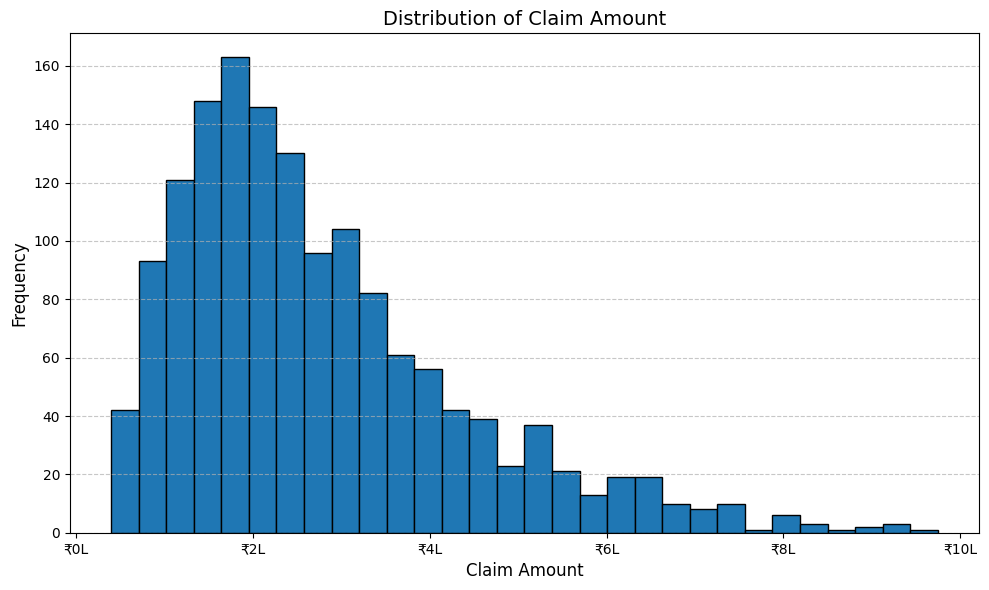

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10,6))  

plt.hist(df['Claim_Amount'], bins=30, edgecolor='black')

plt.title('Distribution of Claim Amount', fontsize=14)
plt.xlabel('Claim Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

plt.tight_layout()
plt.show()

**Insight:**
The distribution of claim amounts is right-skewed, with the majority of claims concentrated between ₹1L–₹4L.

A small number of high-value claims extend beyond ₹8L, forming a long tail. These high-value claims are relatively rare but financially significant.

Such extreme claims are potential fraud indicators, as unusually high payouts may involve exaggerated or suspicious claims requiring deeper investigation.  

***Chart 2: Comparitive Analysis of Claim Amount Distribution Between Fraudulent and Non-Fraudulent Claims***

**Goal:** To compare the distribution of claim amounts between fraudulent and non-fraudulent claims and identify whether claim amount can act as a distinguishing factor for fraud detection.

**Chart Type:** KDE Plot (Kernel Density Estimation)


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

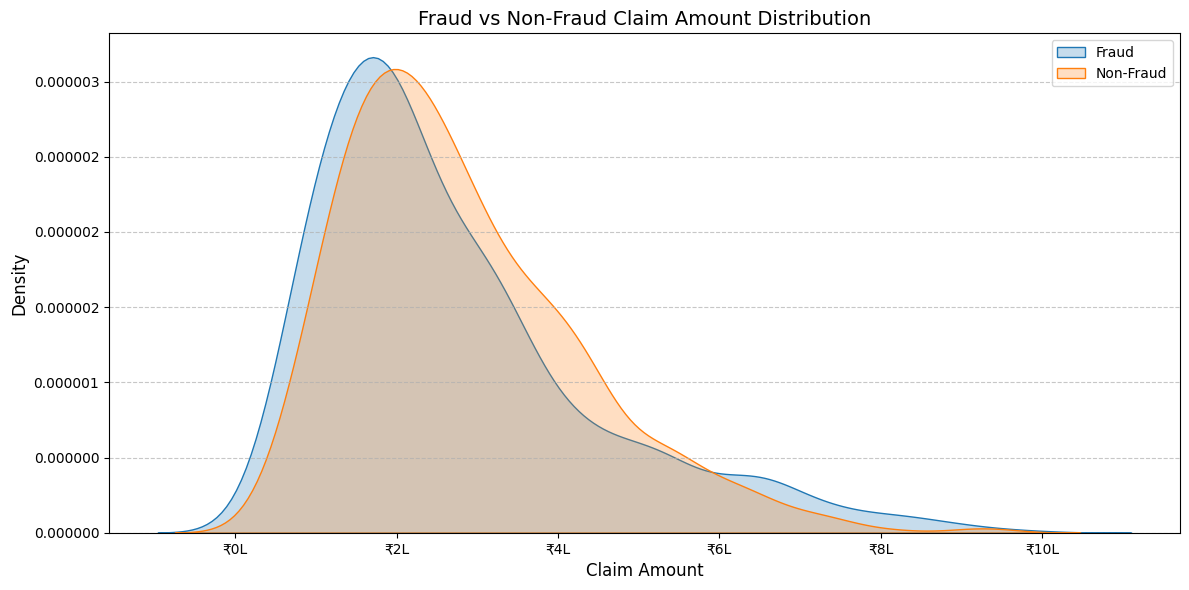

In [37]:
plt.figure(figsize=(12,6))

sns.kdeplot(fraud_df['Claim_Amount'], label='Fraud', fill=True)
sns.kdeplot(non_fraud_df['Claim_Amount'], label='Non-Fraud', fill=True)

plt.title('Fraud vs Non-Fraud Claim Amount Distribution', fontsize=14)
plt.xlabel('Claim Amount', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
import matplotlib.ticker as mticker

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{y:.6f}')
)
plt.tight_layout()
plt.show()

**Insight:** Fraud and non-fraud claim distributions show significant overlap, indicating that claim amount alone is not a strong standalone indicator of fraud. However, fraudulent claims exhibit a slightly heavier tail toward higher values, suggesting that unusually large claims are more likely to be associated with fraud risk, but not exclusively.

***Chart 3: Claim Amount Distribution by Fraud Status***

***Goal:*** To compare the spread, median, and outlier behavior of claim amounts between fraud and non-fraud cases.

**Chart Type:** Box Plot

C:\Users\DELL\AppData\Local\Temp\ipykernel_14272\1525666127.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


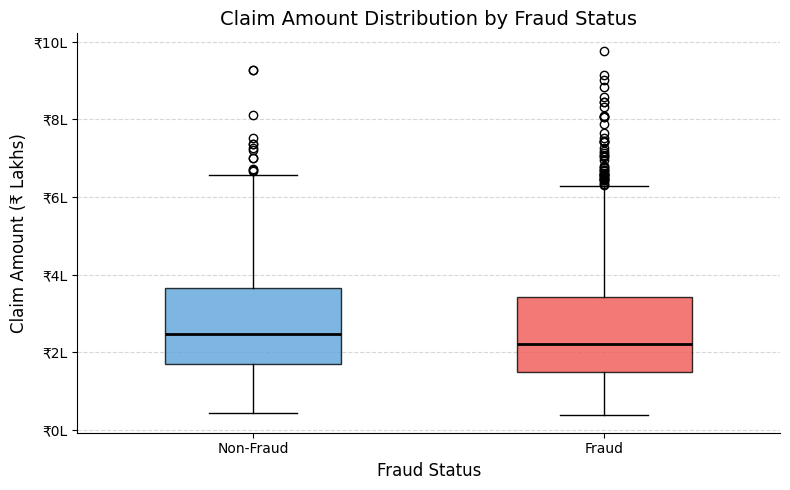

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Data Preparation: Ensure claim amount is clean and usable for analysis
df['Claim_Amount'] = pd.to_numeric(df['Claim_Amount'], errors='coerce')
df = df.dropna(subset=['Claim_Amount'])

plt.figure(figsize=(8,5))

box = plt.boxplot(
    [non_fraud_df['Claim_Amount'], fraud_df['Claim_Amount']],
    labels=['Non-Fraud', 'Fraud'],
    patch_artist=True,
    widths=0.5
)

# Visual Encoding: Distinguish fraud vs non-fraud using contrasting colors
colors = ['#5DA5DA', '#F15854']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Highlight median differences clearly for comparison
for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

plt.title('Claim Amount Distribution by Fraud Status', fontsize=14)
plt.xlabel('Fraud Status', fontsize=12)
plt.ylabel('Claim Amount (₹ Lakhs)', fontsize=12)

# Improve readability: Avoid scientific notation for financial interpretation
plt.ticklabel_format(style='plain', axis='y')

# Format values in Lakhs for business clarity
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

# Subtle grid for easier comparison
plt.grid(axis='y', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Fraud cases exhibit a wider distribution and a higher concentration of extreme outliers compared to non-fraud cases. While median claim amounts remain comparable, fraudulent claims extend more frequently into higher ranges (₹7L+), indicating that unusually large claim values are a strong indicator of potential fraud risk.

***Chart 4: Correlation Analysis of Key Features Influencing Fraud Risk***

**Goal:** Identify relationships between numerical features and detect which variables are strongly associated with fraud behavior.

**Chart Type:** Heatmap (Correlation Matrix)

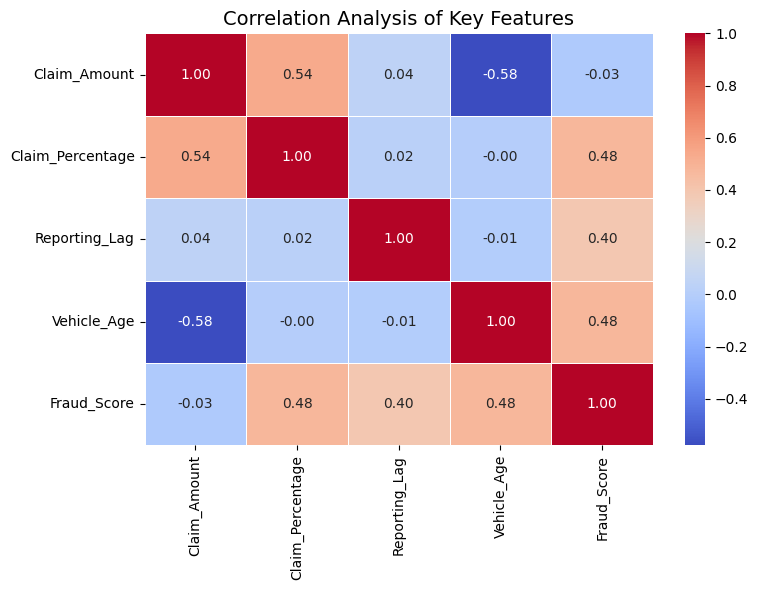

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Analysis: Identify relationships between key fraud-related variables
corr_cols = [
    'Claim_Amount',
    'Claim_Percentage',
    'Reporting_Lag',
    'Vehicle_Age',
    'Fraud_Score'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Analysis of Key Features', fontsize=14)

plt.tight_layout()
plt.show()

**Insight:** Claim Amount and Claim Percentage show a moderate positive correlation, indicating higher claim values tend to represent a larger proportion of insured value. Vehicle Age shows a negative correlation with Claim Amount, suggesting older vehicles tend to have lower claim values. Fraud Score exhibits moderate relationships with multiple features, reinforcing that fraud detection is driven by a combination of factors rather than a single variable.

***Chart 5: Fraud Risk Segmentation: Distribution of Claims Across Risk Levels***

**Goal:** Segment claims into Low, Medium, and High risk categories based on fraud score to identify where fraud is concentrated.

**Chart Type:** Bar Chart (Count Plot with Fraud Split)

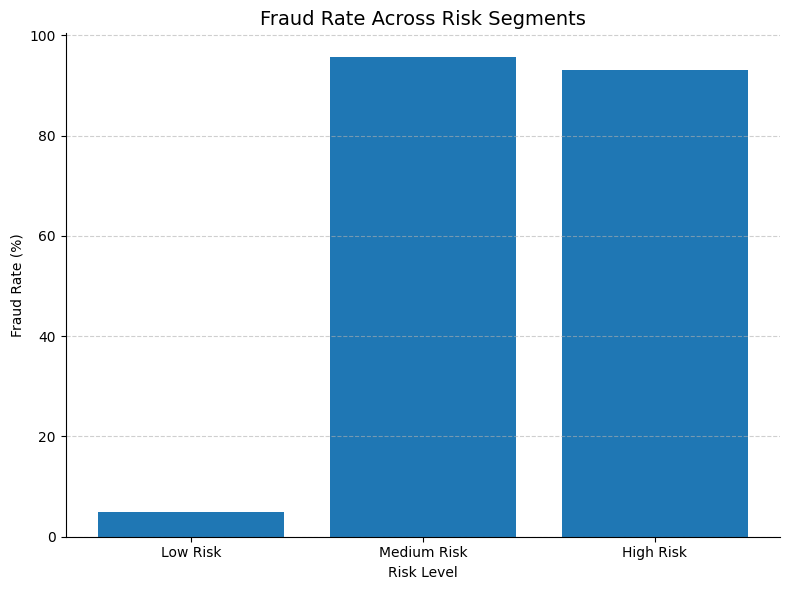

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Risk Segmentation: Categorize claims based on fraud score intensity
df['Risk_Level'] = pd.qcut(
    df['Fraud_Score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Fraud Rate Analysis: Measure percentage of fraudulent claims within each risk segment
risk_summary = df.groupby('Risk_Level')['Final_Fraud_Flag'].mean().reset_index()
risk_summary['Fraud_Percentage'] = risk_summary['Final_Fraud_Flag'] * 100


plt.figure(figsize=(8,6))

plt.bar(risk_summary['Risk_Level'], risk_summary['Fraud_Percentage'])

plt.title('Fraud Rate Across Risk Segments', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Fraud Rate (%)')

# Visual clarity: Highlight trend differences across segments
plt.grid(axis='y', linestyle='--', alpha=0.6)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Fraud rates increase significantly across risk segments, with high-risk claims showing a substantially higher likelihood of fraud compared to low-risk claims. However, the presence of fraud in lower-risk segments indicates that risk scoring is probabilistic rather than definitive, reflecting real-world uncertainty.

***Chart 6: Fraud Indicator Concentration Analysis***

**Goal:** To identify which fraud indicators are triggered most frequently and understand dominant operational fraud patterns across claims.

**Chart Type:** Bar Chart

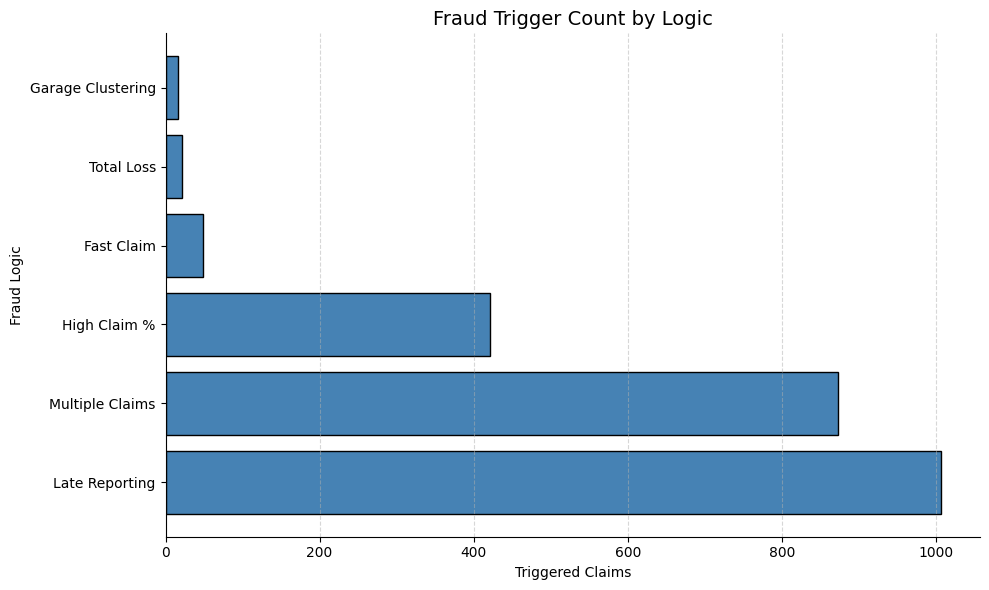

In [43]:
# Fraud Trigger Count by Logic

fraud_logic_counts = {
    'Late Reporting': df['Late_Reporting_Flag'].sum(),
    'Multiple Claims': df['Multiple_Claims_Flag'].sum(),
    'High Claim %': df['High_Claim_Flag'].sum(),
    'Total Loss': df['Total_Loss_Flag'].sum(),
    'Garage Clustering': df['Cluster_Fraud_Flag'].sum(),
    'Fast Claim': df['Fast_Claim_Flag'].sum()
}

logic_df = pd.DataFrame(
    fraud_logic_counts.items(),
    columns=['Fraud Logic', 'Triggered Count']
)

logic_df = logic_df.sort_values(
    by='Triggered Count',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    logic_df['Fraud Logic'],
    logic_df['Triggered Count'],
    color='steelblue',
    edgecolor='black'
)

plt.title('Fraud Trigger Count by Logic', fontsize=14)
plt.xlabel('Triggered Claims')
plt.ylabel('Fraud Logic')

plt.grid(axis='x', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Late reporting and repeated claim activity emerged as the most frequently triggered fraud indicators, suggesting that suspicious behavioral patterns occur more consistently than extreme loss events. Operationally, this indicates that fraud detection systems should prioritize behavioral monitoring alongside financial severity checks.

***Chart 7: Fraud Score Distribution Across Final Fraud Outcomes***

**Goal:** To evaluate how effectively the rule-based fraud scoring system separates fraudulent and non-fraudulent claims based on score distribution patterns.

**Chart Type:** Violin Plot with Strip Plot Overlay

C:\Users\DELL\AppData\Local\Temp\ipykernel_14272\4153604958.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


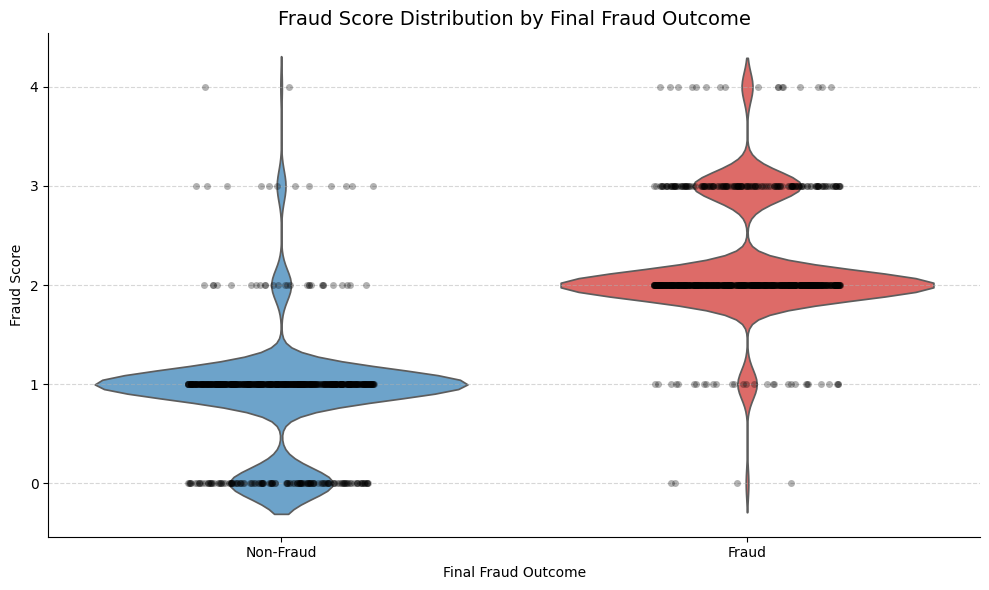

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.violinplot(
    x='Final_Fraud_Flag',
    y='Fraud_Score',
    data=df,
    palette=['#5DA5DA', '#F15854'],
    inner=None
)

sns.stripplot(
    x='Final_Fraud_Flag',
    y='Fraud_Score',
    data=df,
    color='black',
    alpha=0.3,
    jitter=0.2
)

plt.title('Fraud Score Distribution by Final Fraud Outcome', fontsize=14)

plt.xlabel('Final Fraud Outcome')
plt.ylabel('Fraud Score')

plt.xticks(
    [0,1],
    ['Non-Fraud', 'Fraud']
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

***Insight:*** Fraudulent claims exhibit consistently higher fraud scores compared to non-fraudulent claims, validating the effectiveness of the multi-factor fraud scoring framework. While some overlap exists due to controlled noise injection and real-world uncertainty simulation, higher fraud scores remain strongly associated with elevated fraud risk.

***Chart 8: Fraud Logic Co-Occurrence Analysis***

**Goal:** To identify which fraud indicators commonly occur together and uncover compound behavioral fraud patterns across suspicious claims.

**Chart Type:** Heatmap (Fraud Logic Co-Occurrence Matrix)

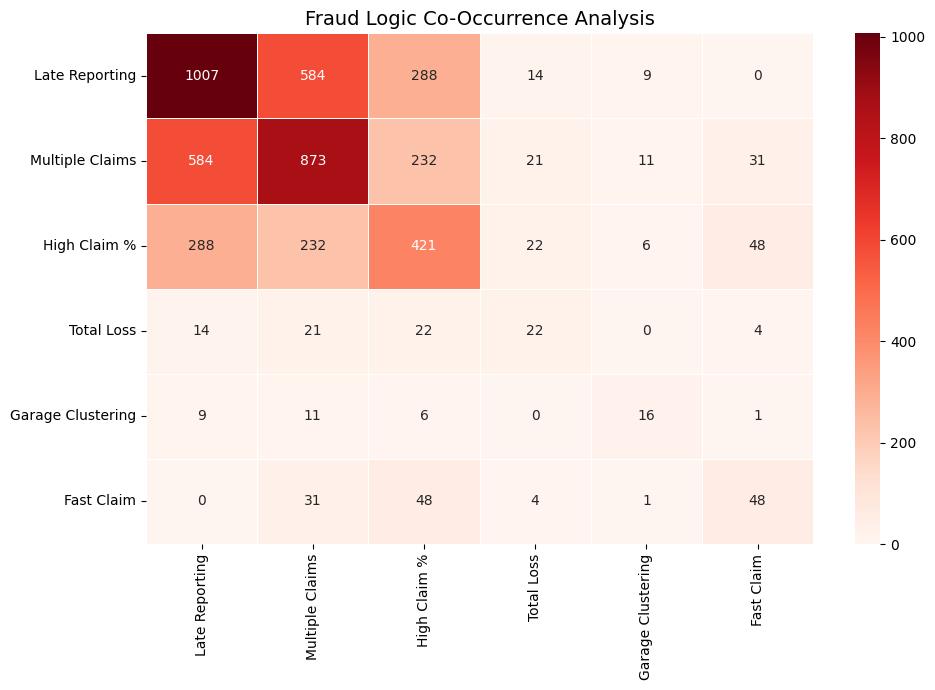

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fraud Logic Columns
logic_cols = [
    'Late_Reporting_Flag',
    'Multiple_Claims_Flag',
    'High_Claim_Flag',
    'Total_Loss_Flag',
    'Cluster_Fraud_Flag',
    'Fast_Claim_Flag'
]

# Convert Boolean Flags to Integer Format
logic_matrix = df[logic_cols].astype(int)

# Co-Occurrence Matrix Calculation
co_occurrence = logic_matrix.T.dot(logic_matrix)

# Rename Labels for Better Readability
co_occurrence.index = [
    'Late Reporting',
    'Multiple Claims',
    'High Claim %',
    'Total Loss',
    'Garage Clustering',
    'Fast Claim'
]

co_occurrence.columns = [
    'Late Reporting',
    'Multiple Claims',
    'High Claim %',
    'Total Loss',
    'Garage Clustering',
    'Fast Claim'
]

# Plot Heatmap
plt.figure(figsize=(10,7))

sns.heatmap(
    co_occurrence,
    annot=True,
    fmt='g',
    cmap='Reds',
    linewidths=0.5
)

plt.title(
    'Fraud Logic Co-Occurrence Analysis',
    fontsize=14
)

plt.tight_layout()

plt.show()

**Insight:**  
Late reporting and multiple claim activity emerged as the strongest co-occurring fraud indicators, suggesting that suspicious claims often involve repeated claim behavior combined with reporting delays. High claim percentage also frequently overlaps with these indicators, reinforcing the presence of compound fraud patterns rather than isolated anomalies. Operationally, this demonstrates that fraud detection becomes significantly stronger when multiple behavioral signals are evaluated together instead of relying on a single trigger.

### 7. Final Summary & Recommendations

***Key Insights***

**1. Fraud risk increases across higher risk segments**  
Claims categorized under medium- and high-risk segments exhibited substantially higher fraud rates compared to low-risk claims. This validates the effectiveness of the rule-based fraud scoring framework in identifying suspicious behavioral patterns.

**2. Claim amount alone is insufficient for fraud detection**  
Although fraudulent claims occasionally involve higher claim amounts and extreme outliers, significant overlap exists between fraudulent and non-fraudulent claim distributions. This indicates that financial severity alone cannot reliably distinguish fraud cases.

**3. Fraudulent claims exhibit stronger behavioral irregularities**  
Late reporting, repeated claim activity, and inflated claim percentages emerged as the most dominant fraud indicators. Co-occurrence analysis further revealed that suspicious claims often involve multiple behavioral triggers occurring simultaneously.

**4. Multi-factor analysis improves fraud detection reliability**  
Correlation and trigger concentration analysis demonstrated that fraud detection becomes significantly more effective when multiple operational indicators are evaluated together instead of relying on isolated signals.

***Business Recommendation***

A practical fraud detection framework should combine behavioral, financial, and operational indicators such as reporting delay, repeated claim activity, claim percentage severity, and contextual risk factors. Multi-trigger evaluation helps improve fraud detection accuracy while reducing false-positive investigations.

***Analytical Note***

To better simulate real-world insurance fraud conditions, controlled uncertainty and overlapping fraud patterns were intentionally incorporated into the dataset. This reflects the practical reality that fraudulent behavior is rarely perfectly deterministic and often overlaps with legitimate claim activity.

--------------------------------------------------------------------------------------------------------------------------------------


**Project Details**

**Project Created by:** Akshaya V.S.

**Date:** 2025 - 2026

**Tools Used:** Python (Pandas, Matplotlib, Seaborn), Jupyter Notebook